In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
# 旋转中心（均值）
x_c = np.array([2,1])
x_c

array([2, 1])

In [5]:
# 主轴
sig = np.array([2,0.5])
sig

array([2. , 0.5])

In [10]:
# 旋转角
theta = np.pi/3
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
R

array([[ 0.5      , -0.8660254],
       [ 0.8660254,  0.5      ]])

$$
\text{标准高斯} \;\xrightarrow{\operatorname{diag}(sig)}\; \text{拉伸椭圆}
\;\xrightarrow{R}\; \text{旋转椭圆}
\;\xrightarrow{+x_C}\; \text{平移到新中心}.
$$

In [8]:
n_points = 10000
X = (R @ np.diag(sig) @ np.random.randn(2,n_points) 
     + np.diag(x_c) @ np.ones((2,n_points)))

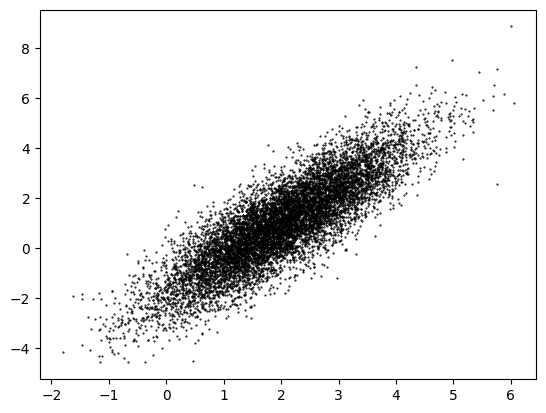

In [16]:
plt.plot(X[0,:], X[1,:], '.',markersize=1, color='black')

下面开始进行PCA

In [21]:
# 均值
X_avg = np.mean(X, axis=1)
X_avg

array([2.0004805 , 1.00286761])

In [32]:
# 计算 B
B = X - np.tile(X_avg,(n_points,1)).T

In [35]:
# 进行SVD分解（为什么是对B/np.sqrt(n_points-1)进行SVD分解？）
U, Sigma, V_T = np.linalg.svd(B/np.sqrt(n_points-1),full_matrices=False)

In [38]:
# 可视化置信区间
theta = np.arange(0,1,0.01) * 2 * np.pi
X_std = U @ np.diag(Sigma) @ np.array([np.cos(theta),np.sin(theta)])

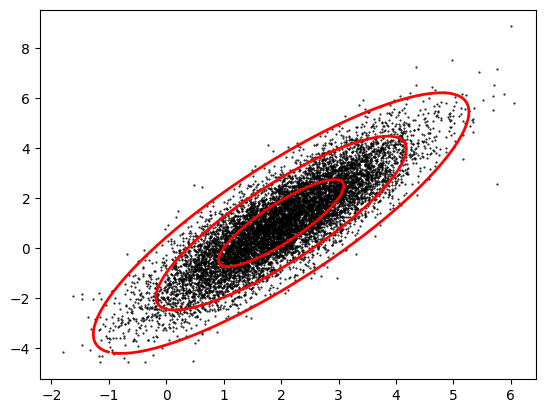

In [41]:
plt.plot(X[0,:], X[1,:], '.',markersize=1, color='black')

plt.plot(X_avg[0] + X_std[0,:],X_avg[1] + X_std[1,:],'-',color = 'red',linewidth=2)
plt.plot(X_avg[0] + 2 * X_std[0,:],X_avg[1] + 2 * X_std[1,:],'-',color = 'red',linewidth=2)
plt.plot(X_avg[0] + 3 * X_std[0,:],X_avg[1] + 3 * X_std[1,:],'-',color = 'red',linewidth=2)
